In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro.distributions as dist
import matplotlib.pyplot as plt
import dynestyx as dsx
from dynestyx import DynamicalModel
from dynestyx import Layouts

# Structured discrete dynamics

In some cases, our dynamics are easier to define on a structured state space. We consider a toy example where our dynamics are given by two components, a latent state $z_k\in \mathbb{R}^{2}$ and an observed **matrix valued state** $x_{k} \in \mathbb{R}^{3 \times 4}$.

$$
\begin{aligned}
z_{k+1} &= \alpha z_{k}\\
x_{k+1} &=  x_k + (Az_{k})\mathbf{1}^\intercal \\
y_k &= \log(1 + \exp(x_k))
\end{aligned}
$$

The matrix $A \in \mathbb{R}^{3\times 2}$ couples the latent space to the observed state. Dynestyx expects all its dynamics to be defined as vectors and while it is possible to formulate the above  as a flat vector $y_k \in \mathbb{R}^{14}$, this can be cumbersome. 

Fortunately, Dynestyx allows us to easily define stuctured dynamics using the `Layouts` utility, which allows to convert between an arbitrary `Pytree` and a flat vector.


In [ ]:
# This will be our structured state.
initial_state = {
    "latent": jnp.array([0.5, -0.5]),
    "observed": jr.normal(jr.PRNGKey(1), (3, 4)),
}

key = jr.PRNGKey(0)
A = jr.normal(key, (3, 2))
alpha = 0.9
# Transition function
def step(state, u, t_now, t_next):
    return {
        "latent": state["latent"]*alpha,
        "observed": state["observed"] + (A @ state["latent"])[:, None]
    }
# Observation function
def observation_function(state, u, t):
    return jnp.log(1 + jnp.exp(state["observed"]))

# We can infer the state and observation layouts from an example state. This allows us to use structured states in our model.
layout = Layouts.from_example(state=initial_state, observation=observation_function(initial_state, None, 0.0))

Once a `Layout` has been defined, we can easily transform between the structured space and the "flat"space.

In [3]:
flat_initial = layout.state.flatten(initial_state) # this is now a vector
assert jnp.array_equal(layout.state.flatten(layout.state.unflatten(flat_initial)), flat_initial)
print("Flat state dimension:", layout.state.dim)
print("Leaf shapes:", jax.tree.map(lambda x: x.shape, initial_state))

Flat state dimension: 14
Leaf shapes: {'latent': (2,), 'observed': (3, 4)}


Dynestyx still expects everything to be a flat vector, but the layout allows us to easily convert between the two. 

In [4]:
initial_condition = dist.Delta(layout.state.flatten(initial_state), event_dim=1)

def evolution(x, u, t_now, t_next):
    # state is received as a flat vector, we need to unflatten it to use the step function
    x = layout.state.unflatten(x)
    x = step(x, u, t_now, t_next)

    # we meed to return the state as a numpyro distribution over the flat space, so we flatten it again and return a Dirac distribution
    x = layout.state.flatten(x)
    return dist.Delta(x, event_dim=1)

def observation_model(x, u, t):
    # state is received as a flat vector, we need to unflatten it to use the observation function
    x = layout.state.unflatten(x)
    y = observation_function(x, u, t)

    # we meed to return the observation as a numpyro distribution over the flat space, so we flatten it again and return a Dirac distribution
    y = layout.observation.flatten(y)
    return dist.Delta(y, event_dim=1)

In [5]:
# Defining the dynamics
dynamics = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=evolution,
    observation_model=observation_model
)

In [6]:
times = jnp.arange(20.0)
result_flat = dsx.simulate(dynamics, rng_key=jr.key(12), predict_times=times, n_simulations=2)

The returned `SimulatedResult` provides results in the flat space, but can use `Layouts` allows to convert to the structured space.

In [7]:
print("Returned states shape are of size (n_simulations, n_times, n_states):", result_flat.states.shape) 
print("Returned observations shape are of size (n_simulations, n_times, n_observations):", result_flat.observations.shape)

result = result_flat.unflatten(layout)

print("The result is now in structured form: ", result.states.keys())
print("The latent state shape is: ", result.states["latent"].shape)
print("The observed state shape is: ", result.states["observed"].shape)

Returned states shape are of size (n_simulations, n_times, n_states): (2, 20, 14)
Returned observations shape are of size (n_simulations, n_times, n_observations): (2, 20, 12)
The result is now in structured form:  dict_keys(['latent', 'observed'])
The latent state shape is:  (2, 20, 2)
The observed state shape is:  (2, 20, 3, 4)


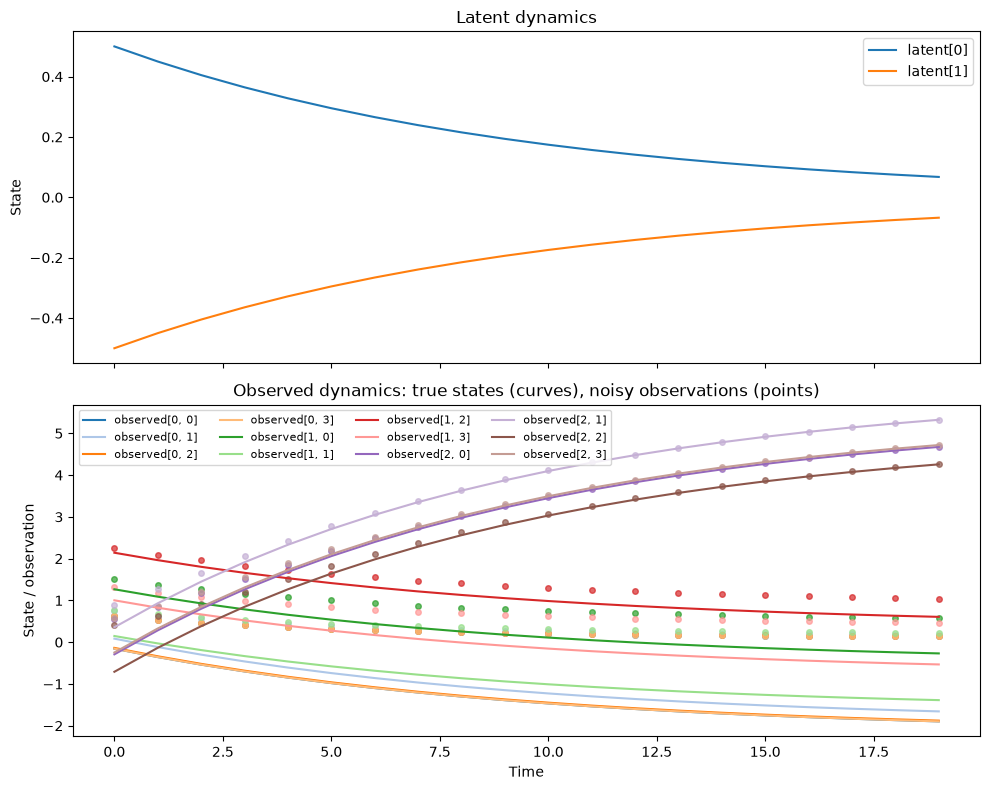

In [8]:
# Plot the first simulated trajectory.
simulation_index = 0
fig, (ax_latent, ax_observed) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

latent = result.states["latent"][simulation_index]
for i in range(latent.shape[-1]):
    ax_latent.plot(times, latent[:, i], label=f"latent[{i}]")
ax_latent.set(title="Latent dynamics", ylabel="State")
ax_latent.legend()

true_observed = result.states["observed"][simulation_index]
actual_observations = result.observations[simulation_index]
colors = plt.get_cmap("tab20")
for i in range(true_observed.shape[1]):
    for j in range(true_observed.shape[2]):
        color = colors(i * true_observed.shape[2] + j)
        ax_observed.plot(
            times, true_observed[:, i, j], color=color, label=f"observed[{i}, {j}]",
        )
        ax_observed.scatter(
            times, actual_observations[:, i, j], color=color, s=16, alpha=0.7,
        )
ax_observed.set(
    title="Observed dynamics: true states (curves), noisy observations (points)",
    xlabel="Time", ylabel="State / observation",
)
ax_observed.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()
